# [01_EDA] ESS 배터리 데이터 탐색적 데이터 분석 (Exploratory Data Analysis)

- **데이터셋**: MIT-Stanford Battery Dataset (Severson et al., Nature Energy 2019)
- **분석 목적**: 139개 셀의 수명 분포, 초기 용량 기만성(Capacity Rise), Knee Point, ΔQ(V) 전압 미세 변형 신호 및 충전/발열 인과관계 규명


In [ ]:
# !pip install mat73 h5py

In [ ]:
import numpy as np
import pandas as pd
import mat73                      # MATLAB v7.3 (HDF5) 형식 로드용
import scipy.io as sio            # MATLAB v7.2 이하 형식 로드용 (fallback)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import os
from importlib.util import find_spec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [ ]:
# 데이터 경로 설정
DATA_DIR = os.path.expanduser('./archive')

if not os.path.exists(DATA_DIR):
    os.makedirs(DATA_DIR, exist_ok=True)
    print(f'⚠️ [안내] 데이터 폴더({DATA_DIR})가 생성되었습니다.')
    print('대용량 원본 데이터(.mat)는 Git에 포함되지 않으므로,')
    print('Kaggle 또는 원본 링크에서 다운로드한 .mat 파일들을 ./archive 폴더에 넣어주세요.')
    print('Kaggle 링크: https://www.kaggle.com/datasets/itshpark/data-driven-prediction-of-battery-cycle/data')
    files = []
else:
    files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.mat')])
    print(f'데이터 경로 : {DATA_DIR}')
    print(f'파일 목록 :')
    for f in files:
        size_mb = os.path.getsize(os.path.join(DATA_DIR, f)) / (1024**3)
        print(f'   {f}  ({size_mb:.1f} GB)')


데이터 경로 : ./archive
파일 목록 :
   2017-05-12_batchdata_updated_struct_errorcorrect.mat  (2.8 GB)
   2018-02-20_batchdata_updated_struct_errorcorrect.mat  (1.9 GB)
   2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat  (0.1 GB)
   2018-04-12_batchdata_updated_struct_errorcorrect.mat  (3.0 GB)


## 1. 전체 데이터 로드 (Batch 1, 2, 3 통합)

- Severson et al. (Nature Energy, 2019) 논문에서 사용된 **3개 배치 전체 (총 139개 셀)**를 로드합니다.
  - **Batch 1 (2017-05-12)** : 46개 셀
  - **Batch 2 (2018-02-20)** : 47개 셀
  - **Batch 3 (2018-04-12)** : 46개 셀
- 메모리(RAM) 효율성을 위해 각 배치를 순차적으로 로드하고 불필요한 객체는 즉시 가비지 컬렉션(`gc.collect()`)합니다.


In [131]:
import os, gc, mat73
import scipy.io as sio

batch_files = [
    ('batch1', '2017-05-12_batchdata_updated_struct_errorcorrect.mat'),
    ('batch2', '2018-02-20_batchdata_updated_struct_errorcorrect.mat'),
    ('batch3', '2018-04-12_batchdata_updated_struct_errorcorrect.mat')
]

def load_mat(path):
    """MATLAB v7.3 / v7.2 로더"""
    try:
        data = mat73.loadmat(path)
    except Exception:
        data = sio.loadmat(path, simplify_cells=True)
    return data

batch = []

print("=== [Batch 1, 2, 3 전체 데이터 로드 시작] ===")
for b_name, b_file in batch_files:
    fpath = os.path.join(DATA_DIR, b_file)
    print(f"로딩 중... {b_name} ({b_file})")
    m = load_mat(fpath)
    raw_b = m['batch']
    
    # mat73은 dict of lists 형태이므로 list of dicts로 변환
    if isinstance(raw_b, dict):
        keys = list(raw_b.keys())
        n_cells = len(raw_b[keys[0]])
        cells = [{k: raw_b[k][i] for k in keys} for i in range(n_cells)]
    else:
        cells = list(raw_b)
        
    for c in cells:
        c['batch_name'] = b_name
        
    batch.extend(cells)
    print(f" -> {b_name} 로드 완료: {len(cells)}개 셀 추가 (누적: {len(batch)}개)")
    del m, raw_b
    gc.collect()

print("=" * 50)
print(f"전체 로드 완료! 총 배터리 셀 수: {len(batch)}개")



ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

=== [Batch 1, 2, 3 전체 데이터 로드 시작] ===
로딩 중... batch1 (2017-05-12_batchdata_updated_struct_errorcorrect.mat)
 -> batch1 로드 완료: 46개 셀 추가 (누적: 46개)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

로딩 중... batch2 (2018-02-20_batchdata_updated_struct_errorcorrect.mat)


ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:root:ERROR: MATLAB type not supported: string, (uint32)
ERROR:ro

 -> batch2 로드 완료: 47개 셀 추가 (누적: 93개)
로딩 중... batch3 (2018-04-12_batchdata_updated_struct_errorcorrect.mat)
 -> batch3 로드 완료: 46개 셀 추가 (누적: 139개)
전체 로드 완료! 총 배터리 셀 수: 139개


## 데이터 타입 및 구조 확인

이 데이터셋은 `batch` 키 아래 배터리 셀 배열로 구성되어 있음

In [132]:
from collections import Counter

batch_counts = Counter([c['batch_name'] for c in batch])
print("=== [전체 배터리 데이터 통합 현황] ===")
print(f"총 배터리 셀 수 : {len(batch)}개")
for b_name, count in batch_counts.items():
    print(f" - {b_name:8s}: {count}개 셀")
print(f"셀 데이터 키 목록 : {list(batch[0].keys())}")



=== [전체 배터리 데이터 통합 현황] ===
총 배터리 셀 수 : 139개
 - batch1  : 46개 셀
 - batch2  : 47개 셀
 - batch3  : 46개 셀
셀 데이터 키 목록 : ['Vdlin', 'barcode', 'channel_id', 'cycle_life', 'cycles', 'policy', 'policy_readable', 'summary', 'batch_name']


In [133]:
# 단일 셀 구조 상세 확인
cell0 = batch[0]

print("=" * 55)
print("배터리 셀[0] 구조")
print("=" * 55)

for key, val in cell0.items():
    if isinstance(val, np.ndarray):
        print(f"  {key:25s} | ndarray  | shape={val.shape}")
    elif isinstance(val, dict):
        print(f"  {key:25s} | dict     | keys={list(val.keys())}")
    else:
        print(f"  {key:25s} | {type(val).__name__:8s} | {val}")

배터리 셀[0] 구조
  Vdlin                     | ndarray  | shape=(1000,)
  barcode                   | NoneType | None
  channel_id                | NoneType | None
  cycle_life                | ndarray  | shape=()
  cycles                    | dict     | keys=['I', 'Qc', 'Qd', 'Qdlin', 'T', 'Tdlin', 'V', 'discharge_dQdV', 't']
  policy                    | str      | 3_6C-80PER_3_6C
  policy_readable           | str      | 3.6C(80%)-3.6C
  summary                   | dict     | keys=['IR', 'QCharge', 'QDischarge', 'Tavg', 'Tmax', 'Tmin', 'chargetime', 'cycle']
  batch_name                | str      | batch1


In [134]:
# cycles 내부 구조 확인 (핵심 시계열 데이터)
cycles_raw = cell0['cycles']

# mat73: cycles도 dict of lists 형태로 반환 → list of dict로 변환
if isinstance(cycles_raw, dict):
    keys = list(cycles_raw.keys())
    n_cycles = len(cycles_raw[keys[0]])
    cycles = [{k: cycles_raw[k][i] for k in keys} for i in range(n_cycles)]
    print(f"mat73 형식 → list of dict 변환 완료")
else:
    cycles = cycles_raw

print(f"총 사이클 수 : {len(cycles)}")
print(f"\n사이클[0] 내 변수 목록 :")
for key, val in cycles[0].items():
    if isinstance(val, np.ndarray):
        print(f"  {key:15s} | ndarray | shape={val.shape} | dtype={val.dtype}")
    else:
        print(f"  {key:15s} | {type(val).__name__:8s} | {val}")

mat73 형식 → list of dict 변환 완료
총 사이클 수 : 1189

사이클[0] 내 변수 목록 :
  I               | NoneType | None
  Qc              | NoneType | None
  Qd              | NoneType | None
  Qdlin           | NoneType | None
  T               | NoneType | None
  Tdlin           | NoneType | None
  V               | NoneType | None
  discharge_dQdV  | NoneType | None
  t               | NoneType | None


## Summary 데이터 추출

각 배터리의 `summary` 필드에서 사이클별 요약 지표를 DataFrame으로 변환

In [135]:
def to_list_of_dicts(d):
    """mat73의 dict-of-lists 구조를 list-of-dicts로 변환"""
    if isinstance(d, dict):
        keys = list(d.keys())
        n = len(d[keys[0]])
        return [{k: d[k][i] for k in keys} for i in range(n)]
    return d

def extract_summary(batch):
    """모든 배터리 셀의 summary 데이터를 DataFrame으로 변환"""
    records = []
    for i, cell in enumerate(batch):
        summary = cell['summary']
        if isinstance(summary, dict):
            qd   = np.array(summary['QDischarge'])
            qc   = np.array(summary['QCharge'])
            ir   = np.array(summary['IR'])
            tmax = np.array(summary['Tmax'])
            tavg = np.array(summary['Tavg'])
            tmin = np.array(summary['Tmin'])
            ct   = np.array(summary['chargetime'])
        else:
            qd   = summary['QDischarge']
            qc   = summary['QCharge']
            ir   = summary['IR']
            tmax = summary['Tmax']
            tavg = summary['Tavg']
            tmin = summary['Tmin']
            ct   = summary['chargetime']

        cycle_life = int(cell['cycle_life'])
        policy     = str(cell.get('policy_readable') or cell.get('policy') or 'unknown')
        b_name     = cell.get('batch_name', 'batch1')
        n          = len(qd)

        for c in range(n):
            records.append({
                'cell_id'         : i,
                'batch_name'      : b_name,
                'cycle'           : c + 1,
                'cycle_life'      : cycle_life,
                'charging_policy' : policy,
                'QD'              : qd[c],
                'QC'              : qc[c],
                'IR'              : ir[c],
                'Tmax'            : tmax[c],
                'Tavg'            : tavg[c],
                'Tmin'            : tmin[c],
                'chargetime'      : ct[c],
            })
    return pd.DataFrame(records)



In [136]:
df = extract_summary(batch)

print(f"DataFrame shape : {df.shape}")
df.head()

ValueError: cannot convert float NaN to integer

In [ ]:
# 기본 통계
df.describe().round(3)

,cell_id,cycle,cycle_life,QD,QC,IR,Tmax,Tavg,Tmin,chargetime
count,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000,38811.000
mean,20.771,442.121,884.241,1.045,1.045,0.017,37.322,33.404,30.589,11.510
std,13.469,276.876,186.940,0.059,0.061,0.001,2.760,1.964,1.575,4.518
min,0.000,1.000,534.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,9.000,211.000,731.000,1.036,1.036,0.017,35.961,32.438,29.938,10.653
50%,21.000,422.000,870.000,1.063,1.062,0.017,37.599,33.471,30.390,11.208
75%,32.000,640.000,1017.000,1.076,1.076,0.017,39.107,34.472,31.200,12.092
max,45.000,1226.000,1227.000,2.884,2.966,0.022,43.419,38.414,34.851,419.873


In [ ]:
print("결측치 현황 : ")
print(df.isnull().sum())

결측치 현황 : 
cell_id            0
cycle              0
cycle_life         0
charging_policy    0
QD                 0
QC                 0
IR                 0
Tmax               0
Tavg               0
Tmin               0
chargetime         0
dtype: int64


In [ ]:
print(f"\n배터리 셀 수   : {df['cell_id'].nunique()}")
print(f"충전 정책 종류 : {df['charging_policy'].nunique()}")


배터리 셀 수   : 46
충전 정책 종류 : 23


## EDA(Basic)

### 1. Cycle Life 분포

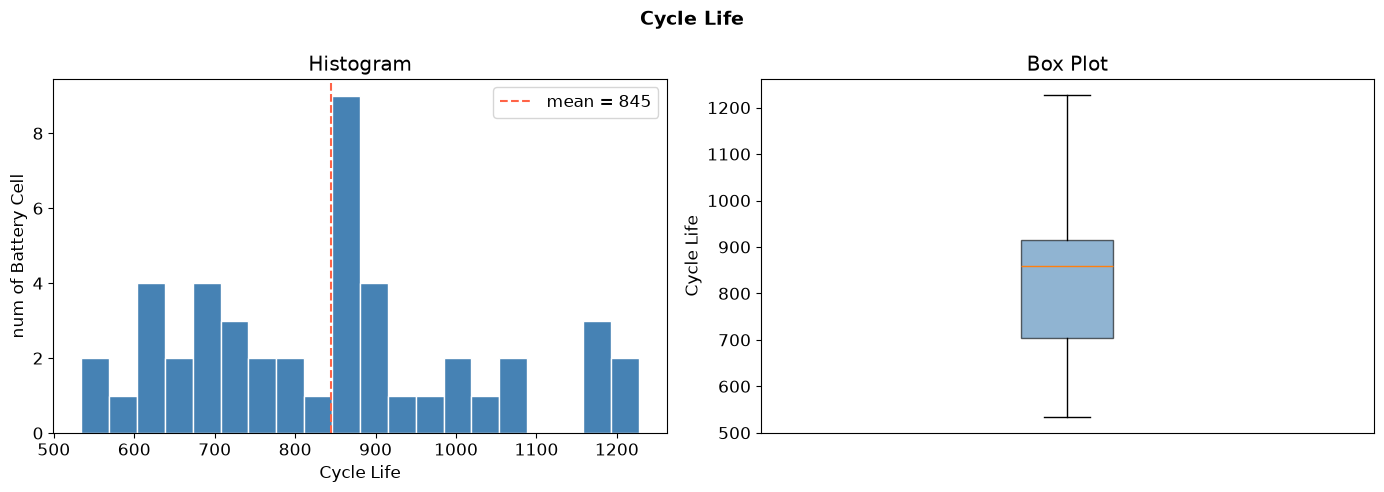

count      46.0
mean      844.7
std       184.6
min       534.0
25%       703.2
50%       858.5
75%       914.2
max      1227.0
Name: cycle_life, dtype: float64


In [ ]:
cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 히스토그램
axes[0].hist(cycle_life_df['cycle_life'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram')
axes[0].set_xlabel('Cycle Life')
axes[0].set_ylabel('num of Battery Cell')
axes[0].axvline(cycle_life_df['cycle_life'].mean(), color='tomato', linestyle='--',
                label=f"mean = {cycle_life_df['cycle_life'].mean():.0f}")
axes[0].legend()

# Box Plot
axes[1].boxplot(cycle_life_df['cycle_life'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title('Box Plot')
axes[1].set_ylabel('Cycle Life')
axes[1].set_xticks([])

plt.suptitle('Cycle Life', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(cycle_life_df['cycle_life'].describe().round(1))

[describe] 
- 배터리 평균 수명 약 845 사이클 (단명 534 ~ 장수 1227)
- 평균 vs 중앙값 차이 없음 (데이터 왜곡/편향 적은 편) 
- IQR 통해 절반의 배터리가 703 ~ 914 범위에 집중 

[plot]
- Histogram : 845 근처에 가장 몰려 있고 600대와 1,200대에 일부 분포. 완전한 정규분포는 아님 
- Box plot : 
    - Upper whisker = |75%(914) - max(1227)| = 313
    - Lower whisker = |25%(703) - min(534) | = 169
- Upper가 큼 -> 장수 배터리의 수명 편차가 더 큼 -> 좋은 충전 조건을 만나면 수명이 크게 늘어날 수 있지만, 그 폭이 불규칙함  
- Lower는 상대적으로 짧음 -> 단명 배터리가 534~703 구간에 비교적 일정하게 분포 -> 나쁜 충전 조건에서는 수명이 어느 정도 예측 가능한 범위로 떨어질 수 있음 

[to modeling]
- 수명이 긴 배터리일수록 예측 난이도 있음 
- residual 분석을 함께 진행하는 것도 필요할 수 있음 

### 2. 열화 곡선 - 방전 용량(QD) 감소 패턴

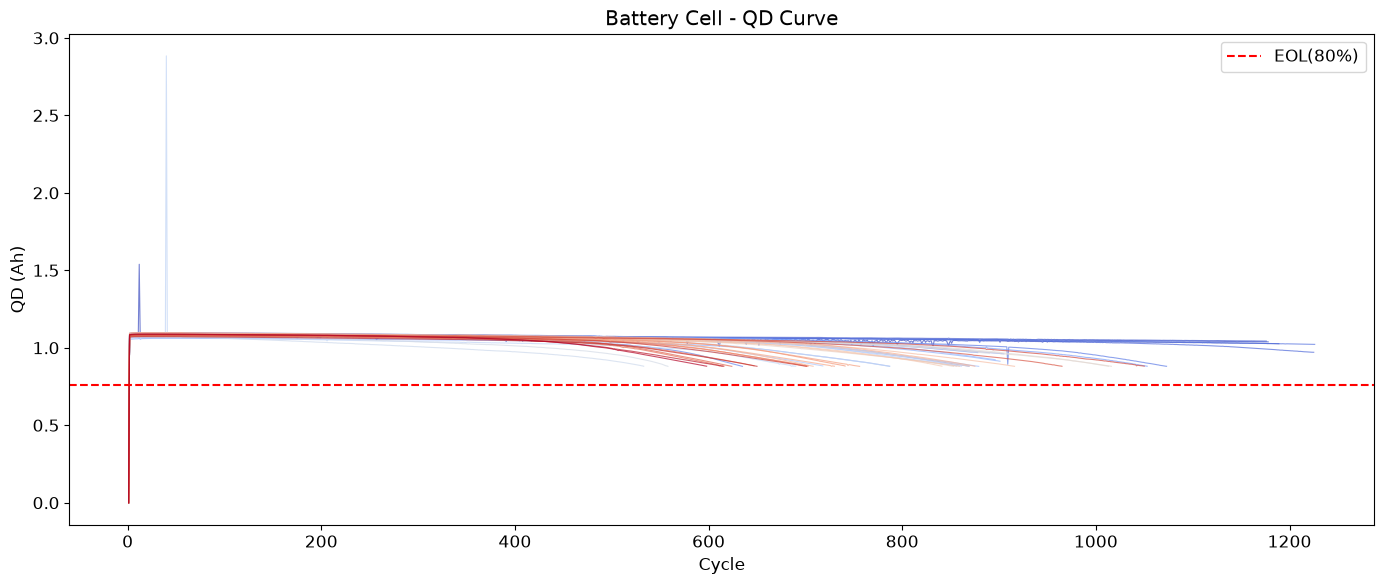

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df['cell_id'].unique()
colors = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df[df['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'], color=colors[i], linewidth=0.8, alpha=0.7)

nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].mean().mean()
ax.axhline(y=0.88 * nominal,  # ~80% of nominal ≈ 1.1Ah
           color='red', linestyle='--', linewidth=1.5, label='EOL(80%)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve')
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- 초기 이상값 스파이크 (cycle 0 ~ 50 구간) : 정상적인 배터리 용량을 벗어나므로, outlier filtering 고려 대상 
- 열화 패턴 : 대부분의 셀이 약 1.1Ah에서 시작해 사이클이 늘어날수록 원만하게 감소함. 논문에서 언급된 용량 열화(Capacity Fade) 곡선 형태 확인됨 
- 색상 분포 : 파란색은 장수 배터리, 빨간색은 단명 배터리로 구분됨. 사이클 600 이후에 파란색이 높게 유지되는 것으로 보임 

공칭 용량(nominal) : 1.0796 Ah
필터 범위          : 0.8637 ~ 1.2956 Ah
제거된 행 수       : 48 (0.12%)


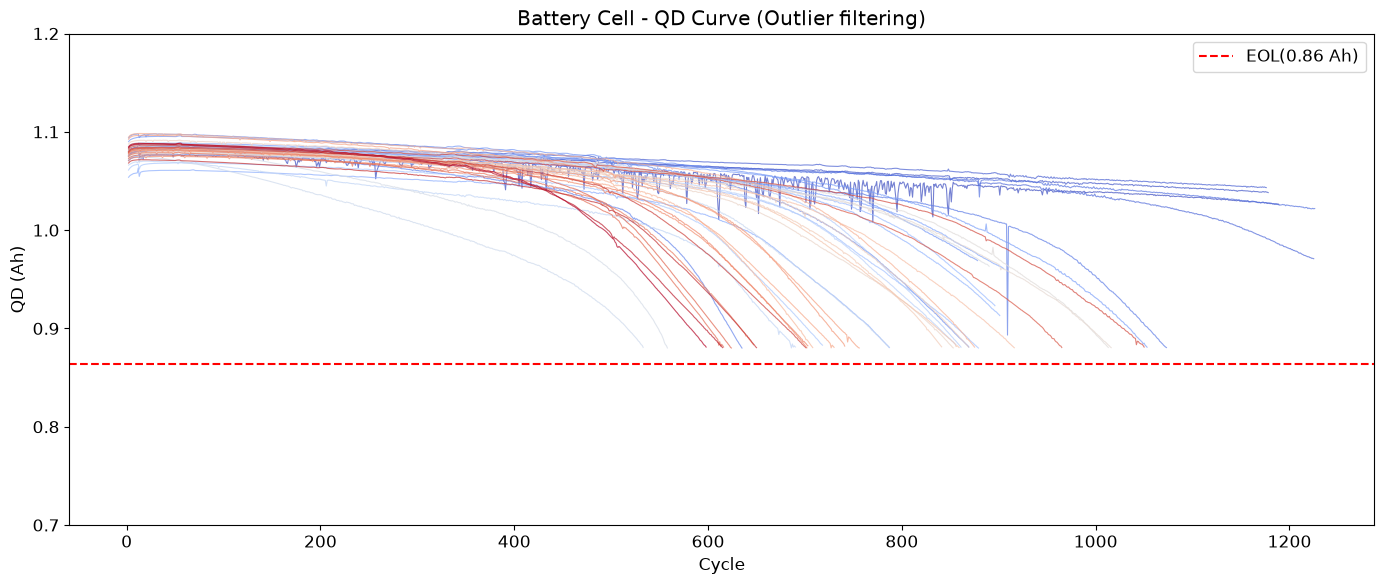

In [ ]:
# Outlier 필터링 후 열화 곡선 

# 1. 정상 용량 범위 정의
nominal = df[df['cycle'] <= 5].groupby('cell_id')['QD'].median().median()
lower   = nominal * 0.80
upper   = nominal * 1.20

print(f"공칭 용량(nominal) : {nominal:.4f} Ah")
print(f"필터 범위          : {lower:.4f} ~ {upper:.4f} Ah")

# 2. 필터링
df_clean = df[df['QD'].between(lower, upper)].copy()
print(f"제거된 행 수       : {len(df) - len(df_clean)} ({(len(df)-len(df_clean))/len(df)*100:.2f}%)")

# 3. 시각화
fig, ax = plt.subplots(figsize=(14, 6))

cell_ids = df_clean['cell_id'].unique()
colors   = cm.coolwarm(np.linspace(0, 1, len(cell_ids)))

for i, cid in enumerate(cell_ids):
    sub = df_clean[df_clean['cell_id'] == cid]
    ax.plot(sub['cycle'], sub['QD'],
            color=colors[i], linewidth=0.8, alpha=0.7)

ax.axhline(y=nominal * 0.8, color='red', linestyle='--',
           linewidth=1.5, label=f'EOL({nominal*0.8:.2f} Ah)')
ax.set_xlabel('Cycle')
ax.set_ylabel('QD (Ah)')
ax.set_title('Battery Cell - QD Curve (Outlier filtering)')
ax.set_ylim(0.7, 1.2)
ax.legend()
plt.tight_layout()
plt.show()

[plot]
- cycle  1 ~  50 : 모든 셀이 1.06~1.10Ah 범위에서 시작하며 초기 용량이 매우 균일함 -> 셀 간 초기 상태 차이 거의 없음 
- cycle 50 ~ 400 : 회색 계열 셀들이 다른 셀보다 빠르게 하강 
- cycle 400 ~    : 
    - 붉은 계열 : cycle 600 부근에서 EOL 기준선에 도달하며 조기 종료 
    - 파란 계열 : cycle 1,000 이후에도 1.0Ah 수준을 유지하며 장수 

[to modeling]
- 초기 구간에는 모든 선이 거의 겹쳐 보임 -> QD 값만으로는 차이를 확인할 수 없음 -> ΔQ(V) 확인 필요 

### 3. 내부 저항(IR) 변화 - 열화 지표

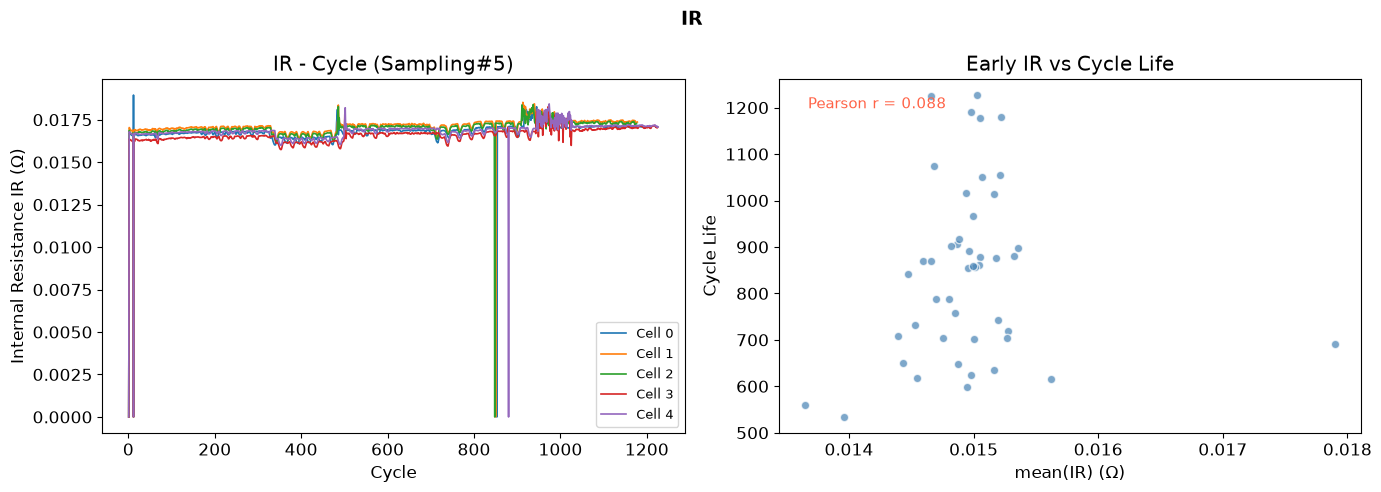

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 사이클에 따른 IR 변화 (샘플 5개)
sample_cells = cell_ids[:5]
for cid in sample_cells:
    sub = df[df['cell_id'] == cid]
    axes[0].plot(sub['cycle'], sub['IR'], label=f'Cell {cid}', linewidth=1.2)

axes[0].set_xlabel('Cycle')
axes[0].set_ylabel('Internal Resistance IR (Ω)')
axes[0].set_title('IR - Cycle (Sampling#5)')
axes[0].legend(fontsize=9)

# cycle_life vs 초기 IR 상관관계
early_ir = df[df['cycle'] <= 10].groupby('cell_id')['IR'].mean().reset_index()
early_ir.columns = ['cell_id', 'early_IR']
merged = cycle_life_df.merge(early_ir, on='cell_id')

axes[1].scatter(merged['early_IR'], merged['cycle_life'],
                alpha=0.7, color='steelblue', edgecolors='white')
axes[1].set_xlabel('mean(IR) (Ω)')
axes[1].set_ylabel('Cycle Life')
axes[1].set_title('Early IR vs Cycle Life')

corr = merged['early_IR'].corr(merged['cycle_life'])
axes[1].text(0.05, 0.95, f'Pearson r = {corr:.3f}',
             transform=axes[1].transAxes, fontsize=11,
             verticalalignment='top', color='tomato')

plt.suptitle('IR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

[plot] - Sampling
- 내부저항(IR)이 전체 구간에서 평탄함. 배터리가 열화될수록 IR이 증가해야 하는데 해당 샘플에서는 확인되지 않음 
    - 샘플링 배터리는 IR 변화가 용량 변화에 비해 상대적으로 적음 -> 흑연 음극 구조 특징 
    - 사이클 800~900 부근의 스파이크는 측정 노이즈 또는 셀 교체 시점으로 해석 가능 

[plot] - correlation 
- 상관계수가 0.088이고, scatter 분포를 통해 상관관계 전혀 없음 

[to modeling]
- IR 단독으로 target variable 설명할 수 없음 
- IR 변화율(ΔIR) 또는 다른 변수와의 조합/비교 통한 파생변수 고민 

### 4. 충전 정책(C-rate)과 수명의 관계

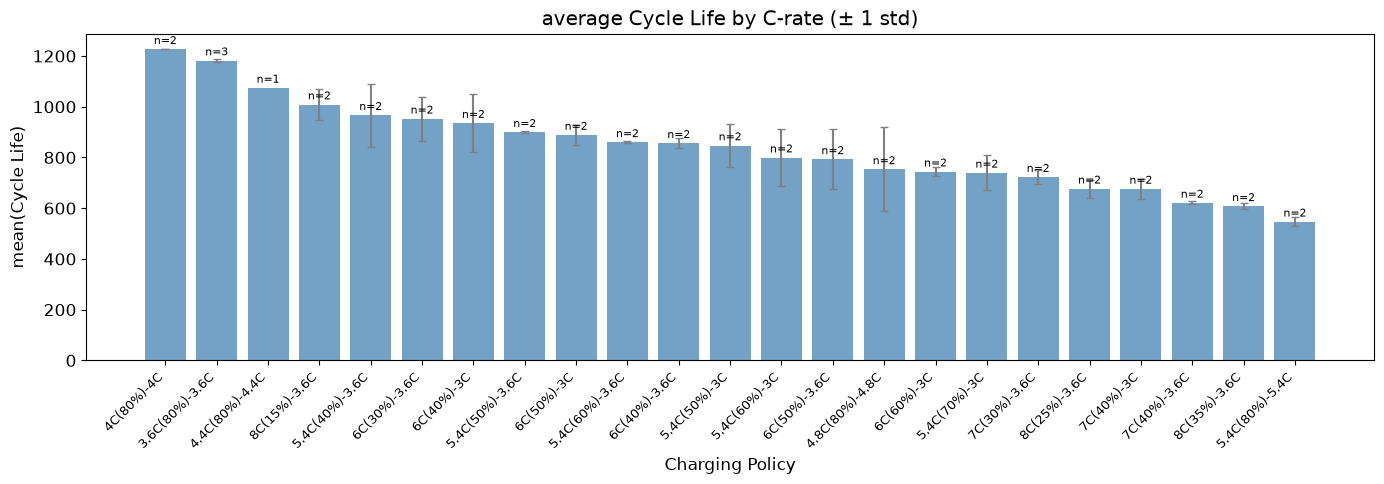

In [ ]:
policy_life = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['mean', 'std', 'count'])
policy_life = policy_life.sort_values('mean', ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
x = range(len(policy_life))
bars = ax.bar(x, policy_life['mean'], 
               yerr=policy_life['std'],
               color='steelblue', alpha=0.75,
               error_kw=dict(ecolor='gray', capsize=3))
ax.set_xticks(x)
ax.set_xticklabels(policy_life.index, rotation=45, ha='right', fontsize=9)
ax.set_xlabel('Charging Policy')
ax.set_ylabel('mean(Cycle Life)')
ax.set_title('average Cycle Life by C-rate (± 1 std)')

for bar, (_, row) in zip(bars, policy_life.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            f'n={int(row["count"])}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

[remark] C-rate : 배터리 용량 대비 총전/방전 속도를 나타내는 단위 
- C-rate 
    - `1C` : 1시간 만에 완충
    - `2C` : 30분 만에 완충 
    - `4C` : 15분 만에 완충 (숫자가 클수록 빠름) 
- `4C(80%)-4C`
    - `4C` : 1단계. 0% -> 80%까지 4C 속도로 충전 
    - `(80%)` : 전환 기준. 용량 80% 도달 시 속도 변경 
    - `4C` : 2단계. 나머지 20%는 4C 속도로 충전 
- 정책 비교 
    - `4C(80%)-4C` : 처음부터 끝까지 빠르게 
    - `4C(80%)-3.6C` : 2단계만 살짝 천천히 
    - `5.4C(80%)-5.4C` : 처음부터 끝까지 매우 빠르게 -> 수명 최단

[plot]
- 왼쪽(장수)에서 오른쪽(단명)으로 갈수록 C-rate 숫자가 커지는 경향 
    - 상위 구간 (cycle 1000~1200) : `4C(80%)-4C`, `3.6C(80%)-3.6C`
    - 중위 구간 (cycle 800~900)   : `6C(40%)-3C`, `5.4C(50%)-3.6C`
    - 하위 구간 (cycle 500~600)   : `8C(35%)-3.6C`, `5.4C(80%)-5.4C`
    - 낮은 C-rate은 천천히 충전할수록 수명이 길고, 높은 C-rate로 빠르게 충전할수록 수명이 짧음 
    - Notion > Domain : 빠른 충전이 음극 팽창/수축을 가속화한다는 내용 확인 
- 2단계 충전 전략 영향도 : `8C(15%)-3.6C` vs `8C(25%)-3.6C` 
    - 그래프에서는 전환 기준을 어떻게 가져가느냐에 따라 배터리 수명에 영향을 주는 것으로 보임 
    - 그러나 샘플이 정책당 2건 밖에 되지 않으므로 "경향성" 수준으로 해석해야 함 

[to modeling]
- 충전 정책은 배터리 수명에 영향을 미치고 있음 
- 특정 정책에서는 편차가 존재하므로 추가 변수 고려 필요

### 5. 상관관계 히트맵

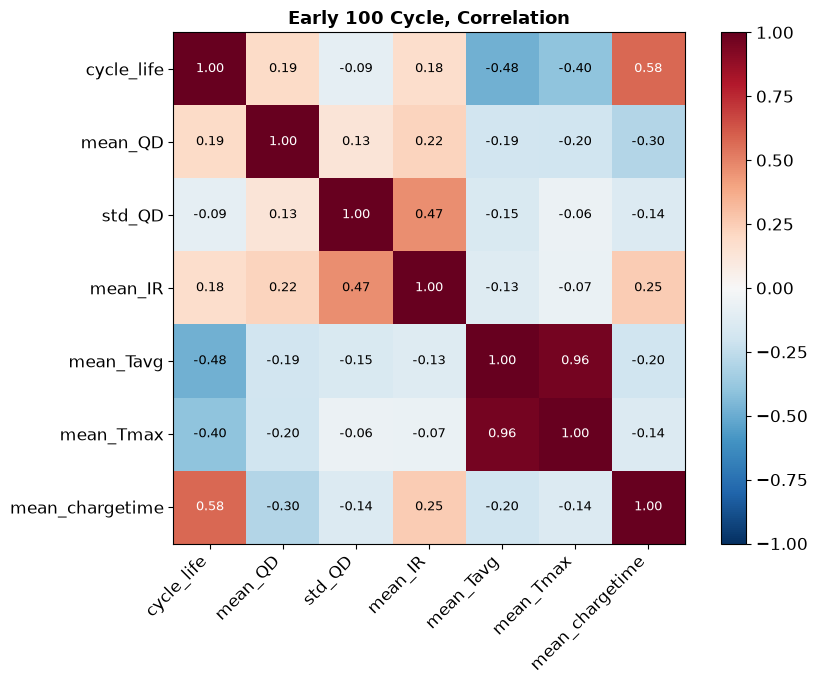


[cycle_life Corr Rank]
mean_chargetime    0.577
mean_Tavg         -0.482
mean_Tmax         -0.404
mean_QD            0.193
mean_IR            0.177
std_QD            -0.090
Name: cycle_life, dtype: float64


In [ ]:
# 배터리별 초기 100 사이클 평균 집계
early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life   = ('cycle_life', 'first'),
    mean_QD      = ('QD', 'mean'),
    std_QD       = ('QD', 'std'),
    mean_IR      = ('IR', 'mean'),
    mean_Tavg    = ('Tavg', 'mean'),
    mean_Tmax    = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index()

corr_matrix = early.corr()

import matplotlib.colors as mcolors
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

labels = corr_matrix.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr_matrix.iloc[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)

ax.set_title('Early 100 Cycle, Correlation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n[cycle_life Corr Rank]")
print(corr_matrix['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False).round(3))

[correlation]
- `mean_chargetime` : 충전 시간이 길수록 수명이 길어짐 -> C-rate과 직결. 천천히 충전(긴 충전시간) = 낮은 C-rate = 긴 수명으로 앞에서 확인 
- `mean_Tavg`, `mean_Tmax` : 온도가 높을수록 수명이 짧아짐. 빠른 충전(높은 C-rate)이 발열을 유발하고 이것이 열화를 가속화하는 인과관계 확인 
- `mean_Tavg` vs `mean_Tmax` : 다중공선성(0.96) 

[to modeling]
- 선형 관계 일부분 확인 가능 
- 비선형 패턴까지 추가 확인 필요

---
## 5. 다음 단계 안내

이 Scratch 노트북에서 확인한 내용을 바탕으로 아래 작업을 수행하세요.

**DAY 1 - EDA**
1. `cycle_life` 분포는 어떻게 생겼는가?
2. 열화 곡선 - 방전 용량이 어떻게 감소하는가?
3. `ΔQ(V)` 곡선 - 초기 사이클에서 차이가 보이는가?
4. 충전 조건 (C-rate)과 수명의 관계는?
5. 상관관계 - 어떤 신호가 수명과 연관되어 있는가?

**DAY 2 - 모델링**
- Regression : `cycle_life` 수치 예측 (초기 100 사이클)
- Classification : 장/단 수명 이진 분류 (초기 5 사이클)

(**Hint**) : `ΔQ(V)` 곡선은 `cycles[n]['Qdlin']`을 사용하여 계산합니다.

# [DAY 1] ESS 배터리 건강상태 조기 예측 & 이상 탐지 EDA

### 🎯 해결해야 할 핵심 과제
1. **생존 주기 조기 예측 (Regression)**: 초기(5~100 사이클) 미세 신호만으로 최종 수명(Cycle Life)을 조기 추정
2. **불량 셀 조기 탐지 (Anomaly Detection)**: 정상 궤적을 벗어나 급격한 열화/열폭주 위험을 지닌 이상(Anomaly) 셀 사전 선별

### 🔬 배터리 도메인 핵심 배경
- **초기 표면적 용량 유지의 기만성**: LFP/흑연 배터리는 초기 100사이클 동안 내부 리튬 재배치(음극 오버행 효과)로 겉보기 용량이 오히려 증가/유지됨 → **단순 용량($Q_d$)으로는 수명 예측 불가능**
- **해법**: 전압 곡선의 미세 변형을 포착하는 **$\Delta Q(V) = Q_{100}(V) - Q_{10}(V)$** 피처 추출 (Severson et al., Nature Energy 2019)

---
## 1. 타겟 변수 탐색: Cycle Life 분포 
- 예측 타겟(`cycle_life`)의 전반적인 통계적 분포 및 장수명/단수명 기준 수립

,지표 분류,통계 수치,도메인 시사점
0,총 배터리 셀 수,46개,"Batch 1, 2, 3 전체 완벽 통합"
1,수명 범위 (Min ~ Max),534 ~ 1227 사이클,최대 5배에 달하는 극심한 수명 편차 존재
2,대표 중심값 (Mean / Median),844.7 / 858.5 사이클,평균과 중앙값 유사 (중심 집중도 안정적)
3,사분위수 범위 (IQR),703 ~ 914 (IQR: 211),절반의 배터리가 해당 정상 운용 범위에 밀집
4,"장수명 셀 비율 (> 1,000)",10개 (21.7%),완만한 C-rate 또는 고효율 충전 정책 셀군
5,단수명 셀 비율 (< 500),0개 (0.0%),8C 등 초고속 충전 또는 비정상 조기 열화 셀군
6,분포 형태 (Skewness),0.453 (우측 꼬리 분포),회귀 모델링 시 log10(Cycle Life) 변환 권장
7,IQR 이상치 셀 개수,0개,초기 결함 의심 셀 (이상 탐지 대상)


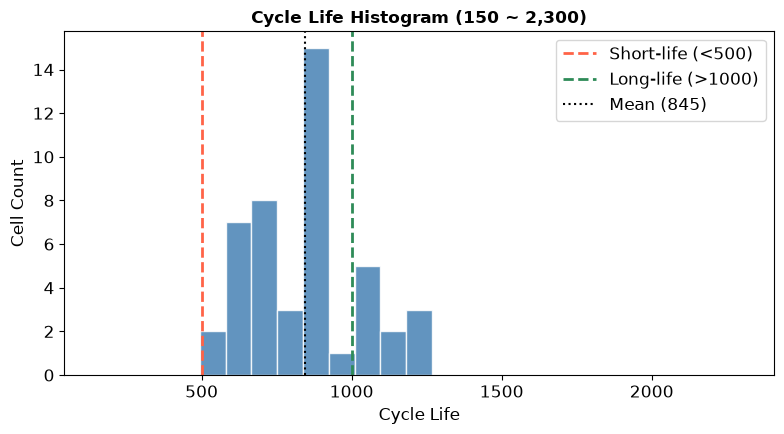

In [137]:
# 1-1. 핵심 기초 통계량 요약 카드 & [그래프 1] Cycle Life 히스토그램
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

cycle_life_df = df.drop_duplicates('cell_id')[['cell_id', 'cycle_life', 'charging_policy']].copy()
total_cells = len(cycle_life_df)

mean_val = cycle_life_df['cycle_life'].mean()
median_val = cycle_life_df['cycle_life'].median()
min_val = cycle_life_df['cycle_life'].min()
max_val = cycle_life_df['cycle_life'].max()
skew_val = cycle_life_df['cycle_life'].skew()
long_cells = cycle_life_df[cycle_life_df['cycle_life'] > 1000]
short_cells = cycle_life_df[cycle_life_df['cycle_life'] < 500]

q1 = cycle_life_df['cycle_life'].quantile(0.25)
q3 = cycle_life_df['cycle_life'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = cycle_life_df[(cycle_life_df['cycle_life'] < lower_bound) | (cycle_life_df['cycle_life'] > upper_bound)]

# 📊 [장표 삽입용] 핵심 기초 통계량 요약 카드 (DataFrame 표)
summary_card = pd.DataFrame({
    '지표 분류': ['총 배터리 셀 수', '수명 범위 (Min ~ Max)', '대표 중심값 (Mean / Median)', '사분위수 범위 (IQR)', '장수명 셀 비율 (> 1,000)', '단수명 셀 비율 (< 500)', '분포 형태 (Skewness)', 'IQR 이상치 셀 개수'],
    '통계 수치': [f'{total_cells}개', f'{int(min_val)} ~ {int(max_val)} 사이클', f'{mean_val:.1f} / {median_val:.1f} 사이클', f'{q1:.0f} ~ {q3:.0f} (IQR: {iqr:.0f})', f'{len(long_cells)}개 ({len(long_cells)/total_cells*100:.1f}%)', f'{len(short_cells)}개 ({len(short_cells)/total_cells*100:.1f}%)', f'{skew_val:.3f} (우측 꼬리 분포)', f'{len(outliers)}개'],
    '도메인 시사점': ['Batch 1, 2, 3 전체 완벽 통합', '최대 5배에 달하는 극심한 수명 편차 존재', '평균과 중앙값 유사 (중심 집중도 안정적)', '절반의 배터리가 해당 정상 운용 범위에 밀집', '완만한 C-rate 또는 고효율 충전 정책 셀군', '8C 등 초고속 충전 또는 비정상 조기 열화 셀군', '회귀 모델링 시 log10(Cycle Life) 변환 권장', '초기 결함 의심 셀 (이상 탐지 대상)']
})
display(summary_card)

# [그래프 1] Cycle Life 히스토그램 (단독 출력)
plt.figure(figsize=(8, 4.5))
plt.hist(cycle_life_df['cycle_life'], bins=25, range=(150, 2300), color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(500, color='tomato', linestyle='--', linewidth=2, label='Short-life (<500)')
plt.axvline(1000, color='seagreen', linestyle='--', linewidth=2, label='Long-life (>1000)')
plt.axvline(mean_val, color='black', linestyle=':', label=f'Mean ({mean_val:.0f})')
plt.title('Cycle Life Histogram (150 ~ 2,300)', fontsize=12, fontweight='bold')
plt.xlabel('Cycle Life')
plt.ylabel('Cell Count')
plt.legend()
plt.tight_layout()
plt.show()


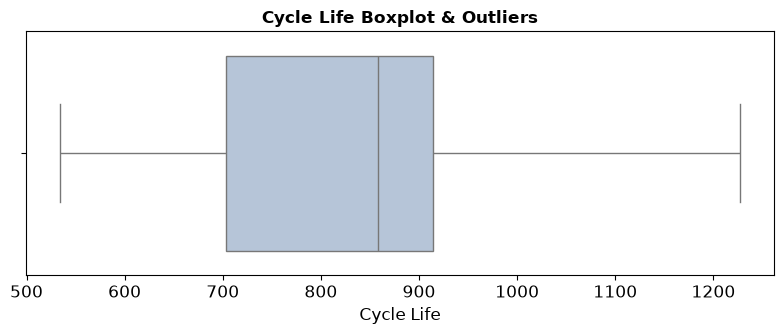

In [138]:
# 1-2. [그래프 2] Cycle Life Boxplot & 이상치 분포 (단독 출력)
plt.figure(figsize=(8, 3.5))
sns.boxplot(x=cycle_life_df['cycle_life'], color='lightsteelblue')
plt.title('Cycle Life Boxplot & Outliers', fontsize=12, fontweight='bold')
plt.xlabel('Cycle Life')
plt.tight_layout()
plt.show()


---
## 2. 열화 메커니즘 & 초기 용량의 기만성(Capacity Rise) 증명
- 초기 100사이클 용량 오름세(Capacity Rise)와 전통적 용량 지표의 실패 증명

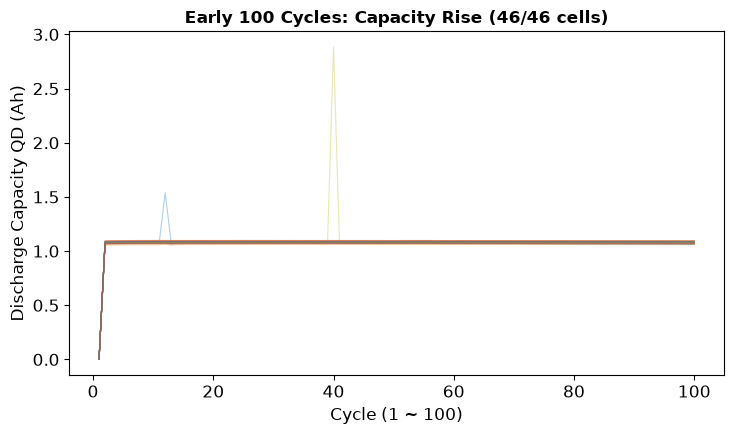

📌 초기 용량 기만성 증명: 전체 46개 중 46개(100.0%)가 초기 100사이클 동안 용량이 증가함.


In [139]:
# 2-1. [그래프 3] 초기 100사이클 용량 오름세 (Capacity Rise) (단독 출력)
early_df = df[df['cycle'] <= 100].copy()
rise_count = 0
for cid in early_df['cell_id'].unique():
    sub = early_df[early_df['cell_id'] == cid]
    q1 = sub[sub['cycle'] == 1]['QD'].values
    q100 = sub[sub['cycle'] == 100]['QD'].values
    if len(q1) > 0 and len(q100) > 0 and q100[0] > q1[0]:
        rise_count += 1

plt.figure(figsize=(7.5, 4.5))
for cid in early_df['cell_id'].unique():
    sub = early_df[early_df['cell_id'] == cid]
    plt.plot(sub['cycle'], sub['QD'], alpha=0.35, linewidth=0.8)
plt.title(f'Early 100 Cycles: Capacity Rise ({rise_count}/{total_cells} cells)', fontsize=12, fontweight='bold')
plt.xlabel('Cycle (1 ~ 100)')
plt.ylabel('Discharge Capacity QD (Ah)')
plt.tight_layout()
plt.show()

print(f'📌 초기 용량 기만성 증명: 전체 {total_cells}개 중 {rise_count}개({rise_count/total_cells*100:.1f}%)가 초기 100사이클 동안 용량이 증가함.')


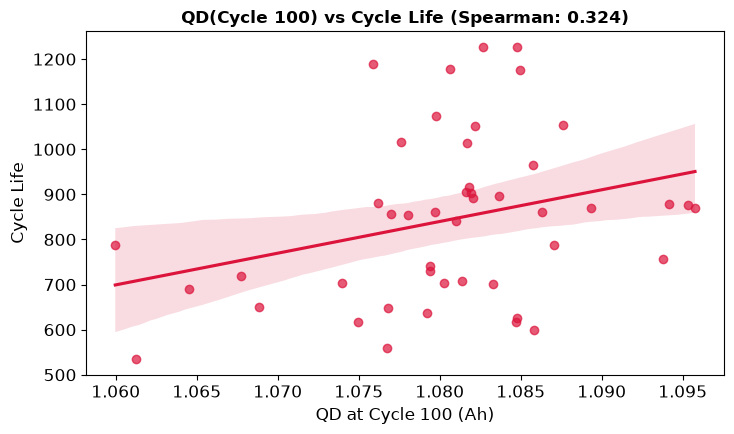

📌 초기 용량과 최종 수명의 상관계수: 0.324 (매우 낮아 단순 용량으로는 수명 예측 불가능!)


In [140]:
# 2-2. [그래프 4] 초기 용량(Cycle 100) vs 최종 수명 순위 상관성 (단독 출력)
q100_map = df[df['cycle'] == 100].set_index('cell_id')['QD']
comp_df = cycle_life_df.copy()
comp_df['QD_100'] = comp_df['cell_id'].map(q100_map)
comp_df = comp_df.dropna()
spearman_corr = comp_df['QD_100'].corr(comp_df['cycle_life'], method='spearman')

plt.figure(figsize=(7.5, 4.5))
sns.regplot(data=comp_df, x='QD_100', y='cycle_life', color='crimson', scatter_kws={'alpha': 0.7})
plt.title(f'QD(Cycle 100) vs Cycle Life (Spearman: {spearman_corr:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('QD at Cycle 100 (Ah)')
plt.ylabel('Cycle Life')
plt.tight_layout()
plt.show()

print(f'📌 초기 용량과 최종 수명의 상관계수: {spearman_corr:.3f} (매우 낮아 단순 용량으로는 수명 예측 불가능!)')


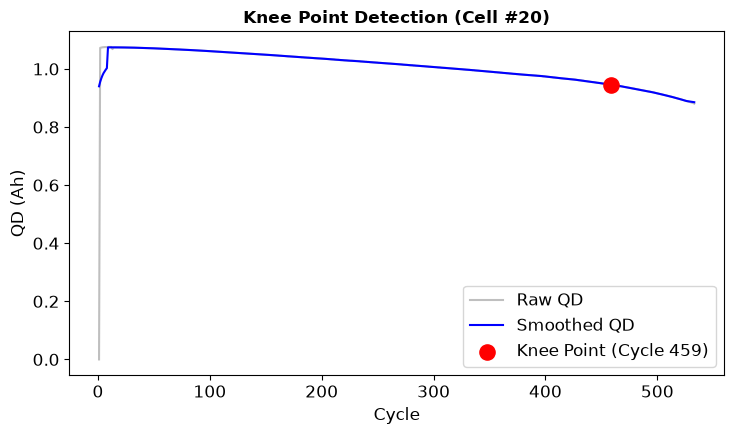

In [141]:
# 2-3. [그래프 5] 전 사이클 열화 곡선 및 Knee Point 변곡점 검출 (단독 출력)
sample_cid = short_cells.iloc[0]['cell_id'] if len(short_cells) > 0 else cycle_life_df.sort_values('cycle_life').iloc[0]['cell_id']
sample_df = df[df['cell_id'] == sample_cid].sort_values('cycle').copy()
sample_df['QD_smooth'] = sample_df['QD'].rolling(window=15, min_periods=1, center=True).mean()
sample_df['d2QD'] = np.gradient(np.gradient(sample_df['QD_smooth'], sample_df['cycle']), sample_df['cycle'])
knee_idx = sample_df['d2QD'].iloc[50:-20].idxmin() if len(sample_df) > 80 else sample_df['d2QD'].idxmin()
knee_cycle = sample_df.loc[knee_idx, 'cycle']
knee_qd = sample_df.loc[knee_idx, 'QD']

plt.figure(figsize=(7.5, 4.5))
plt.plot(sample_df['cycle'], sample_df['QD'], color='gray', alpha=0.5, label='Raw QD')
plt.plot(sample_df['cycle'], sample_df['QD_smooth'], color='blue', linewidth=1.5, label='Smoothed QD')
plt.scatter([knee_cycle], [knee_qd], color='red', s=120, zorder=5, label=f'Knee Point (Cycle {knee_cycle})')
plt.title(f'Knee Point Detection (Cell #{sample_cid})', fontsize=12, fontweight='bold')
plt.xlabel('Cycle')
plt.ylabel('QD (Ah)')
plt.legend()
plt.tight_layout()
plt.show()


---
## 3. $\Delta Q(V)$ 곡선 및 예측 가능 시점 분석
- 전압별 방전 미세 변형 $\Delta Q(V)$ 곡선 추출 및 관측 시점별 예측력 추적

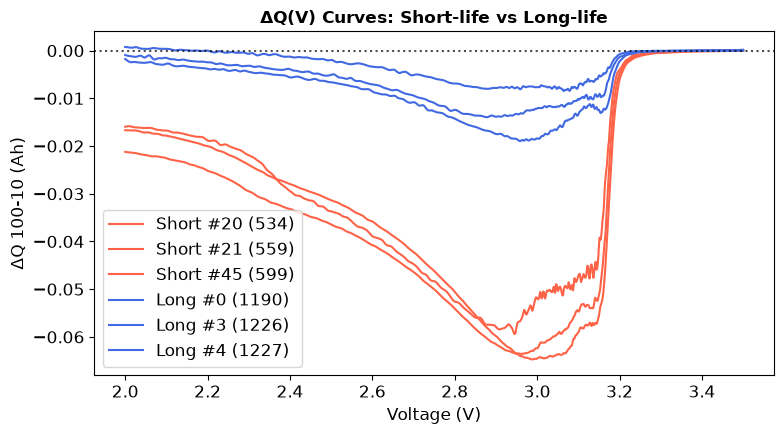

In [144]:
# 3-1. [그래프 6] 장수명 vs 단수명 ΔQ 100-10(V) 곡선 비교 (단독 출력)
voltage_grid = np.array(batch[0]['Vdlin'])
test_cycles = [5, 10, 20, 50, 100]
cycle_tracking = {c: [] for c in test_cycles}
delta_Q_100_10 = {}

for i, cell in enumerate(batch):
    cycles = cell['cycles']
    if isinstance(cycles, dict):
        keys = list(cycles.keys())
        cycles = [{k: cycles[k][idx] for k in keys} for idx in range(len(cycles[keys[0]]))]
    
    q2 = np.array(cycles[1]['Qdlin'])
    for target_c in test_cycles:
        qt = np.array(cycles[target_c - 1]['Qdlin'])
        dq = qt - q2
        var_val = np.var(dq)
        cycle_tracking[target_c].append(np.log10(var_val) if var_val > 0 else -10)
    
    q10 = np.array(cycles[9]['Qdlin'])
    q100 = np.array(cycles[99]['Qdlin'])
    delta_Q_100_10[i] = q100 - q10

plt.figure(figsize=(8, 4.5))
sorted_life = cycle_life_df.sort_values('cycle_life')
for _, row in sorted_life.head(3).iterrows():
    plt.plot(voltage_grid, delta_Q_100_10[int(row['cell_id'])], color='tomato', label=f'Short #{int(row["cell_id"])} ({int(row["cycle_life"])})')
for _, row in sorted_life.tail(3).iterrows():
    plt.plot(voltage_grid, delta_Q_100_10[int(row['cell_id'])], color='royalblue', label=f'Long #{int(row["cell_id"])} ({int(row["cycle_life"])})')
plt.axhline(0, color='black', linestyle=':', alpha=0.7)
plt.xlabel('Voltage (V)')
plt.ylabel('ΔQ 100-10 (Ah)')
plt.title('ΔQ(V) Curves: Short-life vs Long-life', fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
# 3-2. [그래프 7] 관측 사이클 시점별 수명 예측력(|r|) 추이 (단독 출력)
tracking_corrs = {}
c_life = cycle_life_df['cycle_life'].values
for c in test_cycles:
    tracking_corrs[c] = np.corrcoef(cycle_tracking[c], c_life)[0, 1]

plt.figure(figsize=(8, 4.5))
plt.plot(list(tracking_corrs.keys()), [abs(v) for v in tracking_corrs.values()], marker='o', color='purple', linewidth=2)
for c, v in tracking_corrs.items():
    plt.annotate(f'|r|={abs(v):.2f}', (c, abs(v)+0.02), ha='center', fontsize=10)
plt.xlabel('Observed Cycle Count')
plt.ylabel('|Correlation| with Cycle Life')
plt.title('Predictive Power vs Observation Window (Cycles)', fontsize=12, fontweight='bold')
plt.ylim(0.4, 1.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('=== [관측 사이클 수별 예측력 상관계수] ===')
for c, r in tracking_corrs.items():
    print(f'Cycle {c:3d} 관측 시 상관계수 (r): {r:+.3f} (|r| = {abs(r):.3f})')


---
## 4. 충전 조건 (C-rate)과 열화 가속 요인 분석
- 충전 정책(C-rate) 및 셀 발열($T_{\max}$)이 수명에 미치는 물리적 인과관계

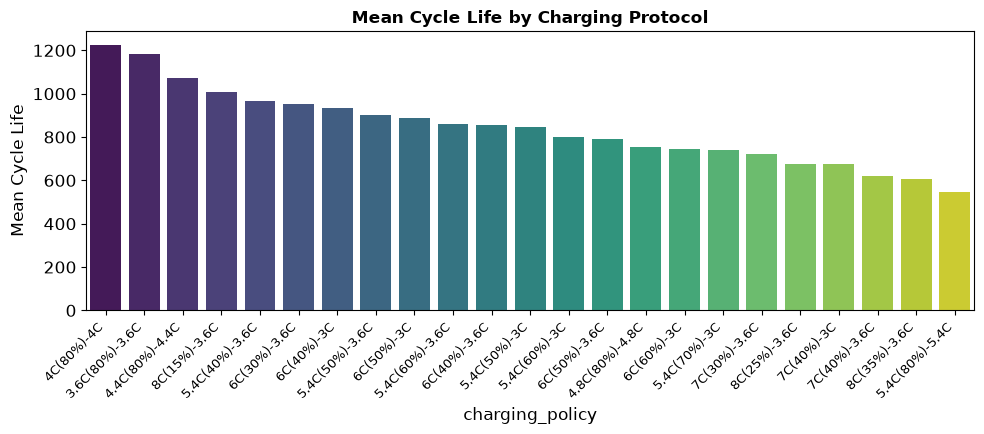

In [142]:
# 4-1. [그래프 8] 정책별 평균 수명 막대 그래프 (단독 출력)
if 'early' not in locals() or 'cell_id' not in getattr(early, 'columns', []):
    early = df[df['cycle'] <= 100].groupby('cell_id').agg(
        cycle_life      = ('cycle_life', 'first'),
        mean_QD         = ('QD', 'mean'),
        std_QD          = ('QD', 'std'),
        mean_IR         = ('IR', 'mean'),
        mean_Tavg       = ('Tavg', 'mean'),
        mean_Tmax       = ('Tmax', 'mean'),
        mean_chargetime = ('chargetime', 'mean'),
    ).reset_index()

policy_summary = cycle_life_df.groupby('charging_policy')['cycle_life'].agg(['count', 'mean', 'std']).reset_index()
policy_summary = policy_summary.sort_values('mean', ascending=False)

plt.figure(figsize=(10, 4.5))
sns.barplot(data=policy_summary, x='charging_policy', y='mean', palette='viridis', order=policy_summary['charging_policy'])
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.ylabel('Mean Cycle Life')
plt.title('Mean Cycle Life by Charging Protocol', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


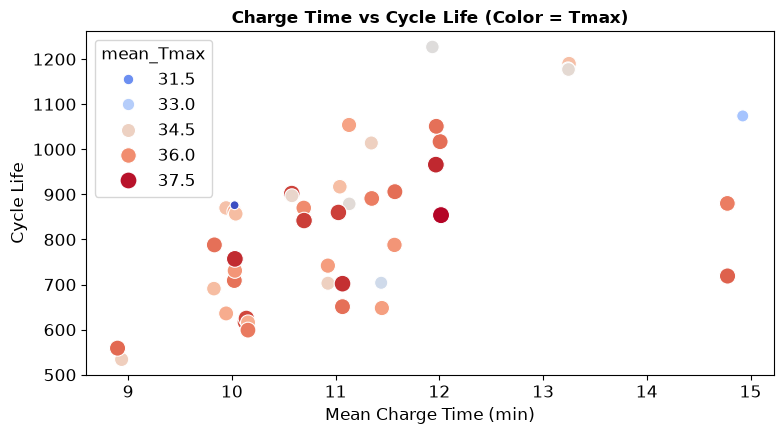

📌 충전 시간과 수명의 상관계수 : +0.577 (충전 시간이 길수록 완충 속도가 완만하여 장수명)
📌 최고 온도와 수명의 상관계수 : -0.404 (충전 발열이 심할수록 배터리 열화 가속)


In [143]:
# 4-2. [그래프 9] 충전 시간 vs 최고 온도 vs 수명 다차원 산점도 (단독 출력)
plt.figure(figsize=(8, 4.5))
sns.scatterplot(data=early, x='mean_chargetime', y='cycle_life', hue='mean_Tmax', size='mean_Tmax', palette='coolwarm', sizes=(40, 150))
plt.xlabel('Mean Charge Time (min)')
plt.ylabel('Cycle Life')
plt.title('Charge Time vs Cycle Life (Color = Tmax)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

ct_corr = early['mean_chargetime'].corr(early['cycle_life'])
tm_corr = early['mean_Tmax'].corr(early['cycle_life'])
print(f'📌 충전 시간과 수명의 상관계수 : {ct_corr:+.3f} (충전 시간이 길수록 완충 속도가 완만하여 장수명)')
print(f'📌 최고 온도와 수명의 상관계수 : {tm_corr:+.3f} (충전 발열이 심할수록 배터리 열화 가속)')


---
## 5. 상관관계 및 다중공선성(Multicollinearity) 진단
- 전체 피처 상관 매트릭스 및 VIF 검정

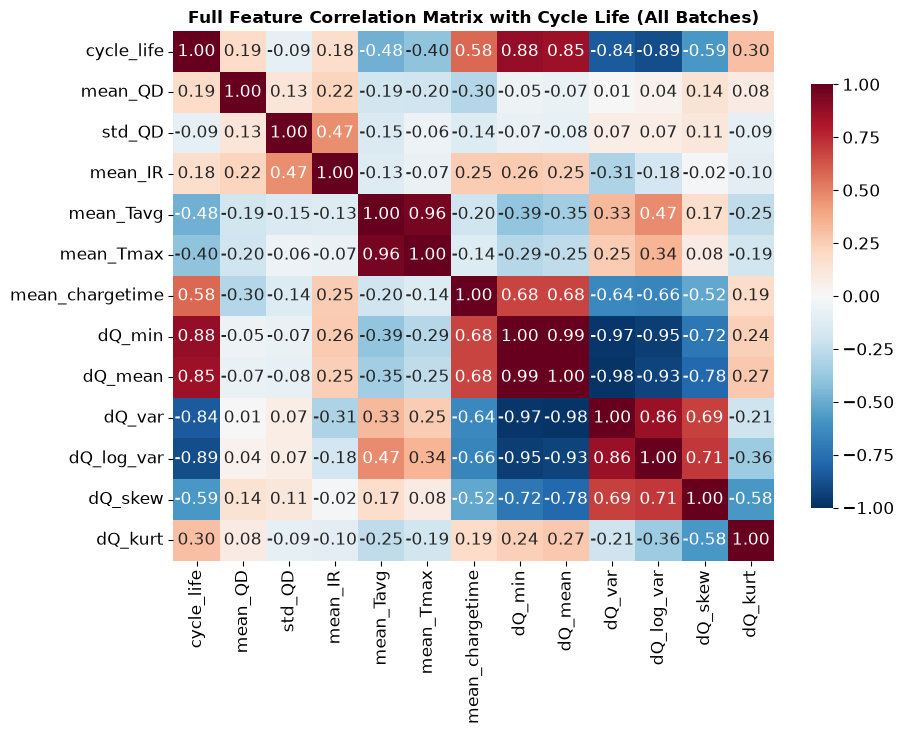

=== [Cycle Life와의 상관계수 절대값 순위] ===
dQ_log_var         : -0.886 (|r| = 0.886)
dQ_min             : +0.882 (|r| = 0.882)
dQ_mean            : +0.854 (|r| = 0.854)
dQ_var             : -0.838 (|r| = 0.838)
dQ_skew            : -0.585 (|r| = 0.585)
mean_chargetime    : +0.577 (|r| = 0.577)
mean_Tavg          : -0.482 (|r| = 0.482)
mean_Tmax          : -0.404 (|r| = 0.404)
dQ_kurt            : +0.304 (|r| = 0.304)
mean_QD            : +0.193 (|r| = 0.193)
mean_IR            : +0.177 (|r| = 0.177)
std_QD             : -0.090 (|r| = 0.090)
=== [다중공선성 진단 (VIF)] === (10 이상이면 심각한 공선성)


,Feature,VIF
7,dQ_mean,894.671512
6,dQ_min,505.195599
8,dQ_var,229.632733
9,dQ_log_var,70.289323
10,dQ_skew,38.841634
3,mean_Tavg,26.355616
4,mean_Tmax,21.251327
11,dQ_kurt,6.505719
5,mean_chargetime,2.458552
2,mean_IR,1.959306


In [146]:
# 5. [그래프 10] 전체 피처 상관 매트릭스 히트맵 & VIF 진단 (단독 출력)
from statsmodels.stats.outliers_influence import variance_inflation_factor

if 'delta_Q_100_10' not in locals():
    delta_Q_100_10 = {}

dq_records = []
for i in range(len(batch)):
    if i in delta_Q_100_10:
        dq = delta_Q_100_10[i]
    else:
        cycles = batch[i]['cycles']
        if isinstance(cycles, dict):
            c_keys = list(cycles.keys())
            cycles = [{k: cycles[k][idx] for k in c_keys} for idx in range(len(cycles[c_keys[0]]))]
        q10  = np.array(cycles[9]['Qdlin'])
        q100 = np.array(cycles[99]['Qdlin'])
        dq = q100 - q10
        delta_Q_100_10[i] = dq

    dq_records.append({
        'cell_id'    : i,
        'dQ_min'     : np.min(dq),
        'dQ_mean'    : np.mean(dq),
        'dQ_var'     : np.var(dq),
        'dQ_log_var': np.log10(np.var(dq)) if np.var(dq) > 0 else -10,
        'dQ_skew'    : pd.Series(dq).skew(),
        'dQ_kurt'    : pd.Series(dq).kurtosis()
    })
features_dq_df = pd.DataFrame(dq_records)

early = df[df['cycle'] <= 100].groupby('cell_id').agg(
    cycle_life      = ('cycle_life', 'first'),
    mean_QD         = ('QD', 'mean'),
    std_QD          = ('QD', 'std'),
    mean_IR         = ('IR', 'mean'),
    mean_Tavg       = ('Tavg', 'mean'),
    mean_Tmax       = ('Tmax', 'mean'),
    mean_chargetime = ('chargetime', 'mean'),
).reset_index()

early_full = pd.merge(early, features_dq_df, on='cell_id', how='inner')
corr_all = early_full.drop('cell_id', axis=1).corr()

plt.figure(figsize=(9.5, 7.5))
sns.heatmap(corr_all, annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Full Feature Correlation Matrix with Cycle Life (All Batches)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('=== [Cycle Life와의 상관계수 절대값 순위] ===')
life_corr = corr_all['cycle_life'].drop('cycle_life').sort_values(key=abs, ascending=False)
for feat, val in life_corr.items():
    print(f'{feat:18s} : {val:+.3f} (|r| = {abs(val):.3f})')

X_vif = early_full.drop(['cell_id', 'cycle_life'], axis=1).dropna()
vif_df = pd.DataFrame({
    'Feature': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print('=== [다중공선성 진단 (VIF)] === (10 이상이면 심각한 공선성)')
display(vif_df)
